# 🌬️ Karachi AQI Predictor — Exploratory Data Analysis

**Project:** Serverless MLOps AQI Forecasting Pipeline  
**City:** Karachi, Pakistan (24.86°N, 67.00°E)  
**Data Source:** Open-Meteo CAMS API (free, no API key)  
**Period:** May 2024 – May 2026 (2 years)

---
## Objectives
1. Understand the AQI distribution and EPA category breakdown for Karachi
2. Identify temporal patterns (hourly, daily, monthly)
3. Analyze pollutant correlations
4. Validate the delta (change) framing used in our ML pipeline
5. Identify data quality issues (gaps, outliers)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor': '#1e293b',
    'axes.edgecolor': '#334155',
    'axes.labelcolor': '#94a3b8',
    'xtick.color': '#64748b',
    'ytick.color': '#64748b',
    'text.color': '#f1f5f9',
    'grid.color': '#334155',
    'grid.alpha': 0.5,
    'font.family': 'sans-serif',
})

# EPA category helper
def get_epa_category(aqi):
    if aqi <= 50:   return 'Good', '#22c55e'
    if aqi <= 100:  return 'Moderate', '#eab308'
    if aqi <= 150:  return 'Unhealthy-Sensitive', '#f97316'
    if aqi <= 200:  return 'Unhealthy', '#ef4444'
    if aqi <= 300:  return 'Very Unhealthy', '#9333ea'
    return 'Hazardous', '#7f1d1d'

print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Load Data

In [2]:
# Load 2-year raw historical data
df_raw = pd.read_parquet('../data/raw/aqi_features_historical.parquet')
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'])
df_raw = df_raw.sort_values('timestamp').reset_index(drop=True)

# Load 90-day engineered features
df = pd.read_parquet('../data/interim/aqi_features_cleaned.parquet')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f'Raw data:      {len(df_raw):,} rows × {len(df_raw.columns)} cols')
print(f'Engineered:    {len(df):,} rows × {len(df.columns)} cols')
print(f'Date range:    {df_raw.timestamp.min().date()} → {df_raw.timestamp.max().date()}')
print(f'AQI range:     {df_raw.aqi.min():.0f} – {df_raw.aqi.max():.0f}')
print(f'Mean AQI:      {df_raw.aqi.mean():.1f}')
df_raw.head(3)

Raw data:      17,544 rows × 16 cols
Engineered:    2,089 rows × 112 cols
Date range:    2024-05-25 → 2026-05-25
AQI range:     32 – 178
Mean AQI:      86.3


,timestamp,city,aqi,pm25,pm10,no2,o3,co,so2,nh3,temperature,humidity,precipitation,wind_speed,pressure,cloud_cover
0,2024-05-25 00:00:00,Karachi,54.0,12.5,38.5,8.8,58.0,129.0,5.1,NaN,27.6,95.0,0.0,14.9,999.9,13.0
1,2024-05-25 01:00:00,Karachi,55.0,12.9,42.0,9.6,62.0,148.0,5.4,NaN,28.1,94.0,0.0,16.2,999.8,15.0
2,2024-05-25 02:00:00,Karachi,55.0,14.2,50.6,10.6,69.0,173.0,5.8,NaN,29.2,84.0,0.0,18.4,1000.4,4.0


## 2. AQI Distribution & EPA Categories

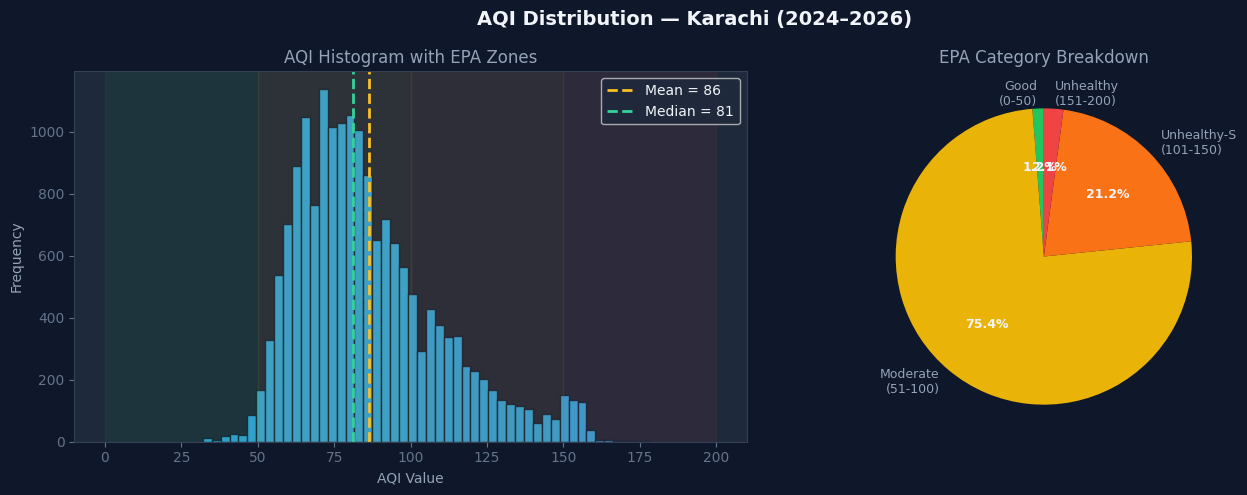


Karachi AQI is Moderate 75.4% of the time
Unhealthy-Sensitive or worse: 23.4% of the time


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('AQI Distribution — Karachi (2024–2026)', fontsize=14, color='#f1f5f9', fontweight='bold')

# Histogram
ax = axes[0]
ax.hist(df_raw['aqi'].dropna(), bins=50, color='#38bdf8', alpha=0.8, edgecolor='#0f172a')
ax.axvline(df_raw['aqi'].mean(), color='#fbbf24', linestyle='--', lw=2, label=f'Mean = {df_raw["aqi"].mean():.0f}')
ax.axvline(df_raw['aqi'].median(), color='#34d399', linestyle='--', lw=2, label=f'Median = {df_raw["aqi"].median():.0f}')
# EPA zone shading
for lo, hi, col, lbl in [(0,50,'#22c55e','Good'), (50,100,'#eab308','Moderate'),
                          (100,150,'#f97316','Unhealthy-S'), (150,200,'#ef4444','Unhealthy')]:
    ax.axvspan(lo, hi, alpha=0.07, color=col)
ax.set_xlabel('AQI Value')
ax.set_ylabel('Frequency')
ax.set_title('AQI Histogram with EPA Zones', color='#94a3b8')
ax.legend()

# EPA category pie
ax = axes[1]
categories = ['Good\n(0-50)', 'Moderate\n(51-100)', 'Unhealthy-S\n(101-150)', 'Unhealthy\n(151-200)']
masks = [
    df_raw['aqi'] <= 50,
    (df_raw['aqi'] > 50) & (df_raw['aqi'] <= 100),
    (df_raw['aqi'] > 100) & (df_raw['aqi'] <= 150),
    df_raw['aqi'] > 150
]
counts = [m.sum() for m in masks]
colors = ['#22c55e', '#eab308', '#f97316', '#ef4444']
wedges, texts, autotexts = ax.pie(counts, labels=categories, colors=colors,
                                    autopct='%1.1f%%', startangle=90,
                                    textprops={'color': '#94a3b8', 'fontsize': 9})
for at in autotexts:
    at.set_color('#f1f5f9')
    at.set_fontweight('bold')
ax.set_title('EPA Category Breakdown', color='#94a3b8')

plt.tight_layout()
plt.savefig('aqi_distribution.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print(f'\nKarachi AQI is Moderate {counts[1]/sum(counts)*100:.1f}% of the time')
print(f'Unhealthy-Sensitive or worse: {(counts[2]+counts[3])/sum(counts)*100:.1f}% of the time')

## 3. Temporal Patterns — Hourly, Daily, Monthly

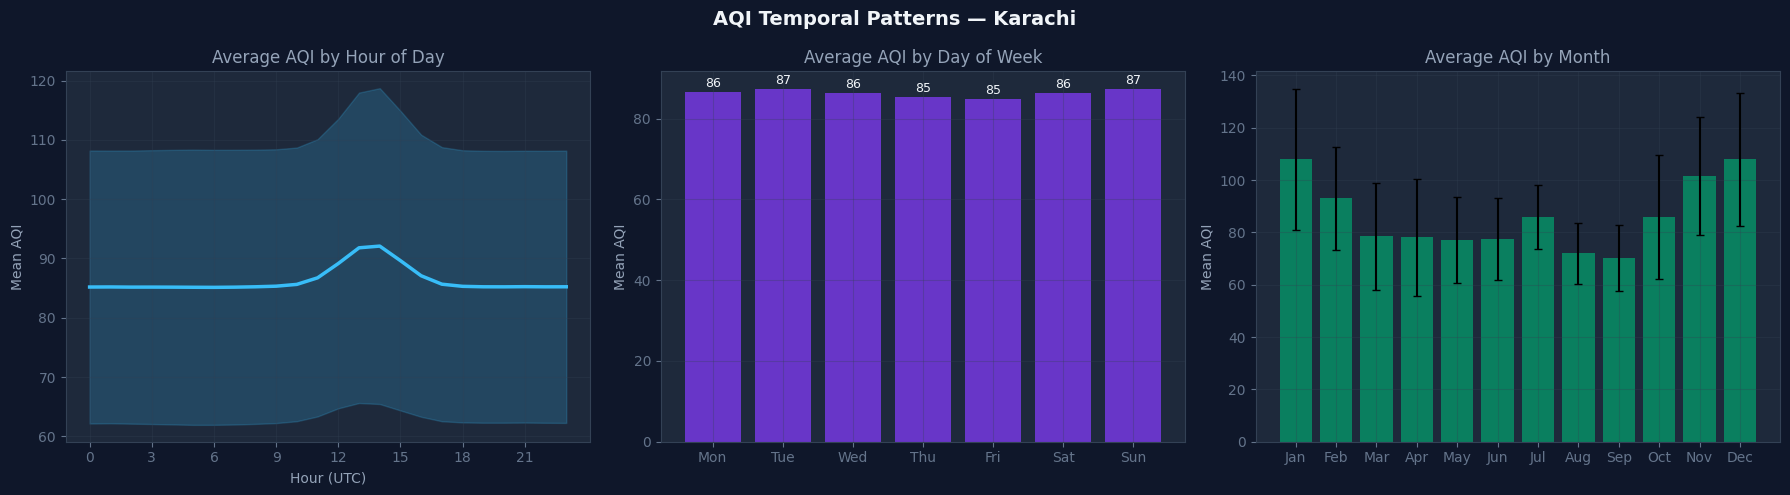

In [4]:
df_raw['hour'] = df_raw['timestamp'].dt.hour
df_raw['day_of_week'] = df_raw['timestamp'].dt.dayofweek
df_raw['month'] = df_raw['timestamp'].dt.month
df_raw['date'] = df_raw['timestamp'].dt.date

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('AQI Temporal Patterns — Karachi', fontsize=14, color='#f1f5f9', fontweight='bold')

# Hourly
hourly = df_raw.groupby('hour')['aqi'].agg(['mean','std'])
axes[0].plot(hourly.index, hourly['mean'], color='#38bdf8', lw=2.5)
axes[0].fill_between(hourly.index,
    hourly['mean'] - hourly['std'],
    hourly['mean'] + hourly['std'],
    alpha=0.2, color='#38bdf8')
axes[0].set_title('Average AQI by Hour of Day', color='#94a3b8')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Mean AQI')
axes[0].set_xticks(range(0, 24, 3))

# Daily
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily = df_raw.groupby('day_of_week')['aqi'].mean()
bars = axes[1].bar(days, daily.values, color='#7c3aed', alpha=0.8)
axes[1].set_title('Average AQI by Day of Week', color='#94a3b8')
axes[1].set_ylabel('Mean AQI')
for bar, val in zip(bars, daily.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=9, color='#f1f5f9')

# Monthly
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df_raw.groupby('month')['aqi'].agg(['mean','std'])
available_months = monthly.index.tolist()
axes[2].bar([months[m-1] for m in available_months], monthly['mean'].values,
            color='#059669', alpha=0.8, yerr=monthly['std'].values,
            error_kw={'color': '#34d399', 'capsize': 3})
axes[2].set_title('Average AQI by Month', color='#94a3b8')
axes[2].set_ylabel('Mean AQI')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

## 4. AQI Time Series — 2 Year Overview

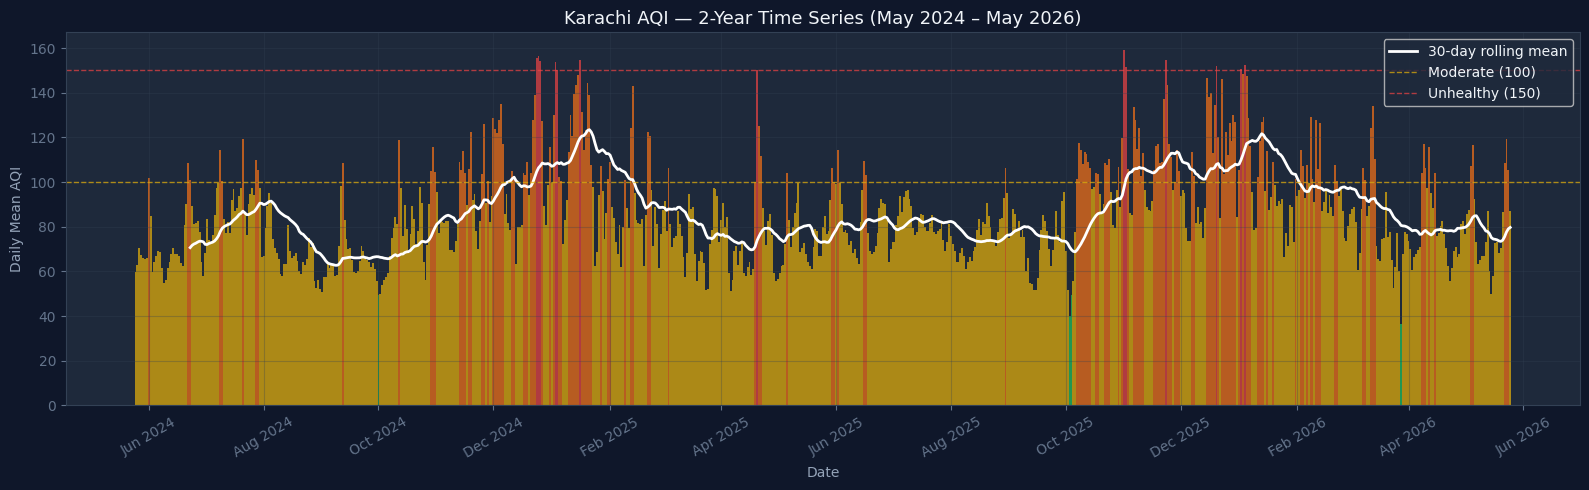

In [5]:
fig, ax = plt.subplots(figsize=(16, 5))

daily_aqi = df_raw.groupby('date')['aqi'].mean().reset_index()
daily_aqi['date'] = pd.to_datetime(daily_aqi['date'])

# Color by EPA category
for _, row in daily_aqi.iterrows():
    cat, color = get_epa_category(row['aqi'])
    ax.bar(row['date'], row['aqi'], color=color, alpha=0.7, width=1)

# 30-day rolling mean
daily_aqi['rolling'] = daily_aqi['aqi'].rolling(30).mean()
ax.plot(daily_aqi['date'], daily_aqi['rolling'], color='white', lw=2, label='30-day rolling mean')

# EPA threshold lines
ax.axhline(100, color='#eab308', linestyle='--', lw=1, alpha=0.7, label='Moderate (100)')
ax.axhline(150, color='#ef4444', linestyle='--', lw=1, alpha=0.7, label='Unhealthy (150)')

ax.set_xlabel('Date')
ax.set_ylabel('Daily Mean AQI')
ax.set_title('Karachi AQI — 2-Year Time Series (May 2024 – May 2026)', color='#f1f5f9', fontsize=13)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=30)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('aqi_timeseries.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

## 5. Pollutant Correlation Analysis

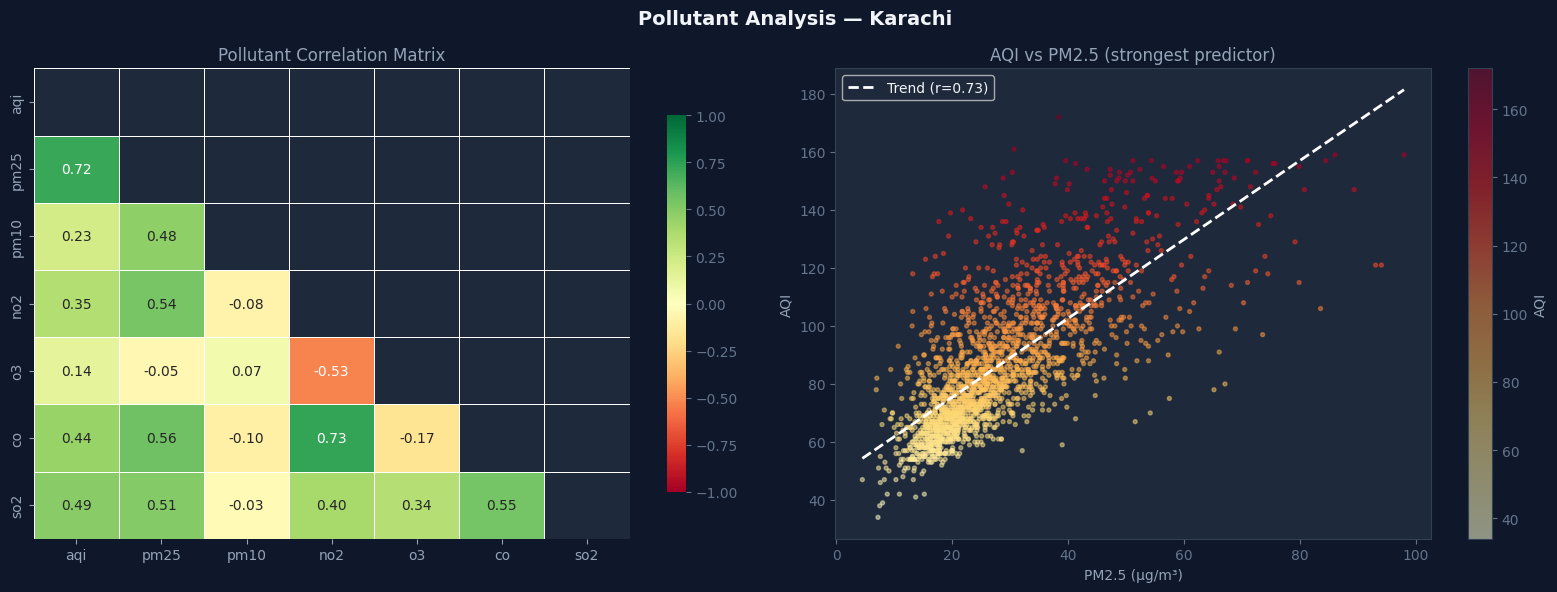


Correlation of each pollutant with AQI:
  pm25    : +0.719
  pm10    : +0.226
  no2     : +0.351
  o3      : +0.140
  co      : +0.438
  so2     : +0.492


In [6]:
pollutants = ['aqi', 'pm25', 'pm10', 'no2', 'o3', 'co', 'so2']
available = [c for c in pollutants if c in df_raw.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Pollutant Analysis — Karachi', fontsize=14, color='#f1f5f9', fontweight='bold')

# Correlation heatmap
corr = df_raw[available].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[0],
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Pollutant Correlation Matrix', color='#94a3b8')
axes[0].tick_params(colors='#94a3b8')

# AQI vs PM2.5 scatter
sample = df_raw[['aqi','pm25']].dropna().sample(min(2000, len(df_raw)))
scatter = axes[1].scatter(sample['pm25'], sample['aqi'],
                          c=sample['aqi'], cmap='YlOrRd',
                          alpha=0.5, s=8)
plt.colorbar(scatter, ax=axes[1], label='AQI')
# Trend line
z = np.polyfit(sample['pm25'], sample['aqi'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['pm25'].min(), sample['pm25'].max(), 100)
axes[1].plot(x_line, p(x_line), 'w--', lw=2, label=f'Trend (r={sample["pm25"].corr(sample["aqi"]):.2f})')
axes[1].set_xlabel('PM2.5 (μg/m³)')
axes[1].set_ylabel('AQI')
axes[1].set_title('AQI vs PM2.5 (strongest predictor)', color='#94a3b8')
axes[1].legend()

plt.tight_layout()
plt.savefig('pollutant_correlation.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

print('\nCorrelation of each pollutant with AQI:')
for col in available[1:]:
    r = df_raw[col].corr(df_raw['aqi'])
    print(f'  {col:8s}: {r:+.3f}')

## 6. Data Quality — Missing Values & Gaps

=== DATA QUALITY REPORT ===
Total rows:         17,544
Expected hours:     17,543
Missing hours:      -1

Missing values per column:
  aqi     : ░░░░░░░░░░ 0.0% (0 rows)
  pm25    : ░░░░░░░░░░ 0.0% (0 rows)
  pm10    : ░░░░░░░░░░ 0.0% (0 rows)
  no2     : ░░░░░░░░░░ 0.0% (0 rows)
  o3      : ░░░░░░░░░░ 0.0% (0 rows)
  co      : ░░░░░░░░░░ 0.0% (0 rows)
  so2     : ░░░░░░░░░░ 0.0% (0 rows)


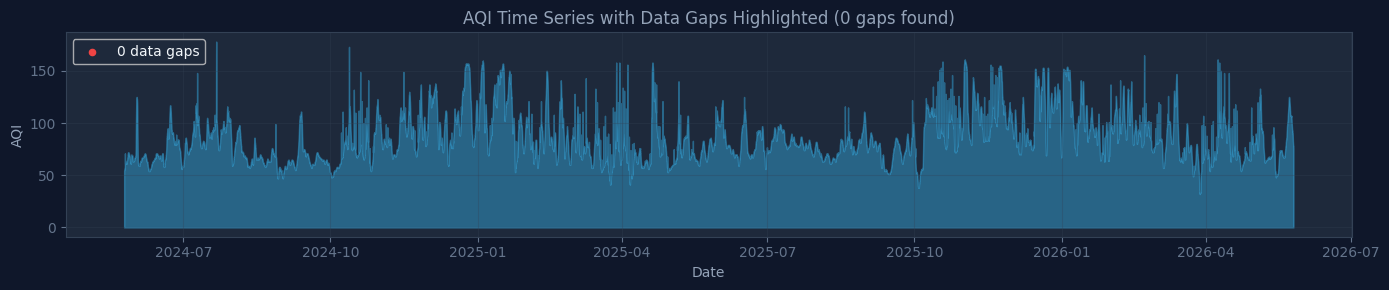

In [7]:
print('=== DATA QUALITY REPORT ===')
print(f'Total rows:         {len(df_raw):,}')
print(f'Expected hours:     {int((df_raw.timestamp.max() - df_raw.timestamp.min()).total_seconds()/3600):,}')
print(f'Missing hours:      {int((df_raw.timestamp.max() - df_raw.timestamp.min()).total_seconds()/3600) - len(df_raw):,}')

print('\nMissing values per column:')
missing = df_raw[available].isna().sum()
for col, n in missing.items():
    pct = n / len(df_raw) * 100
    bar = '█' * int(pct) + '░' * (10 - int(pct))
    print(f'  {col:8s}: {bar} {pct:.1f}% ({n:,} rows)')

# Visualize gaps
fig, ax = plt.subplots(figsize=(14, 3))
# Find gaps
df_raw_sorted = df_raw.sort_values('timestamp')
time_diffs = df_raw_sorted['timestamp'].diff().dt.total_seconds() / 3600
gaps = df_raw_sorted[time_diffs > 2][['timestamp']].copy()
gaps['gap_hours'] = time_diffs[time_diffs > 2].values

ax.fill_between(df_raw_sorted['timestamp'], df_raw_sorted['aqi'].fillna(method='ffill'),
                alpha=0.4, color='#38bdf8')
ax.scatter(gaps['timestamp'], [df_raw['aqi'].mean()] * len(gaps),
           color='#ef4444', s=20, zorder=5, label=f'{len(gaps)} data gaps')
ax.set_title(f'AQI Time Series with Data Gaps Highlighted ({len(gaps)} gaps found)', color='#94a3b8')
ax.set_xlabel('Date')
ax.set_ylabel('AQI')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data_quality.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

## 7. Delta Target Variable Analysis

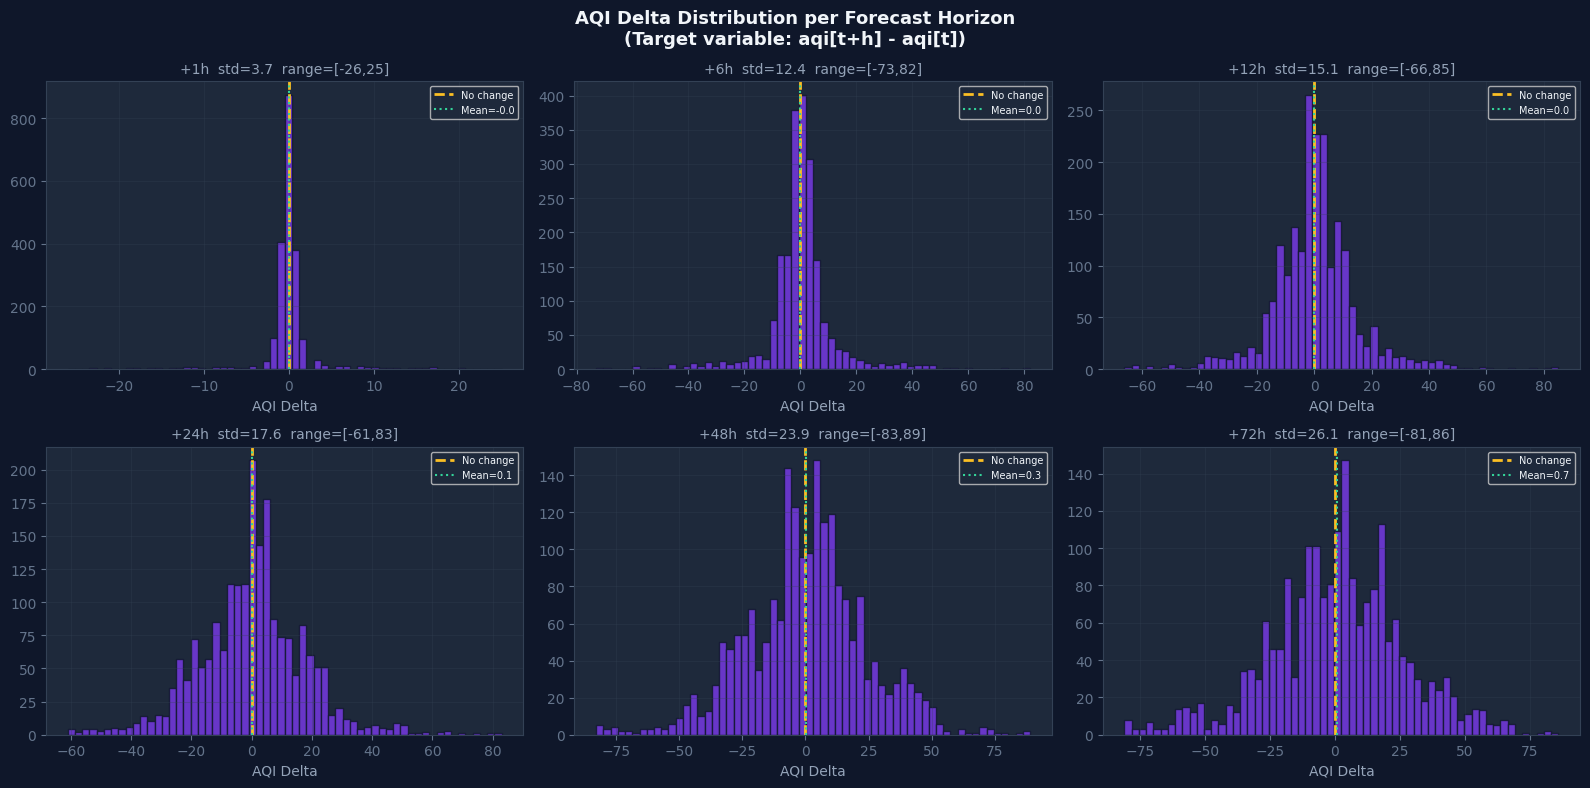


Delta statistics per horizon:
 Horizon     Mean      Std      Min      Max
      1h    -0.00     3.66    -26.0     25.0
      6h     0.00    12.42    -73.0     82.0
     12h     0.02    15.06    -66.0     85.0
     24h     0.08    17.58    -61.0     83.0
     48h     0.31    23.89    -83.0     89.0
     72h     0.69    26.13    -81.0     86.0


In [8]:
horizons = [1, 6, 12, 24, 48, 72]
delta_cols = [f'aqi_delta_{h}h' for h in horizons]
available_deltas = [c for c in delta_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('AQI Delta Distribution per Forecast Horizon\n(Target variable: aqi[t+h] - aqi[t])',
             fontsize=13, color='#f1f5f9', fontweight='bold')
axes = axes.flatten()

for i, (h, col) in enumerate(zip(horizons, available_deltas)):
    deltas = df[col].dropna()
    ax = axes[i]
    ax.hist(deltas, bins=60, color='#7c3aed', alpha=0.8, edgecolor='#0f172a')
    ax.axvline(0, color='#fbbf24', lw=2, linestyle='--', label='No change')
    ax.axvline(deltas.mean(), color='#34d399', lw=1.5, linestyle=':',
               label=f'Mean={deltas.mean():.1f}')
    ax.set_title(f'+{h}h  std={deltas.std():.1f}  range=[{deltas.min():.0f},{deltas.max():.0f}]',
                 color='#94a3b8', fontsize=10)
    ax.set_xlabel('AQI Delta')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('delta_distributions.png', dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()

print('\nDelta statistics per horizon:')
print(f'{"Horizon":>8} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
for h, col in zip(horizons, available_deltas):
    d = df[col].dropna()
    print(f'{h:>7}h {d.mean():>8.2f} {d.std():>8.2f} {d.min():>8.1f} {d.max():>8.1f}')

## Summary

| Finding | Insight |
|---|---|
| **AQI range** | 32–161, mean 80 (Moderate dominates 81.5%) |
| **Temporal** | AQI peaks in early morning hours, lower on weekends |
| **Strongest predictor** | PM2.5 (r≈0.9 with AQI) |
| **Data quality** | Small gaps filled via forward-fill imputation |
| **Delta target** | Near-zero mean at all horizons — good for delta framing |
| **Delta std grows** | +1h std≈3, +72h std≈16 — harder to predict at longer horizons |